In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('economic_index.csv')

In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
df.drop(columns=['Unnamed: 0','year','month'],inplace=True)

In [6]:
df.head(4)

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293


In [7]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [9]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [10]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

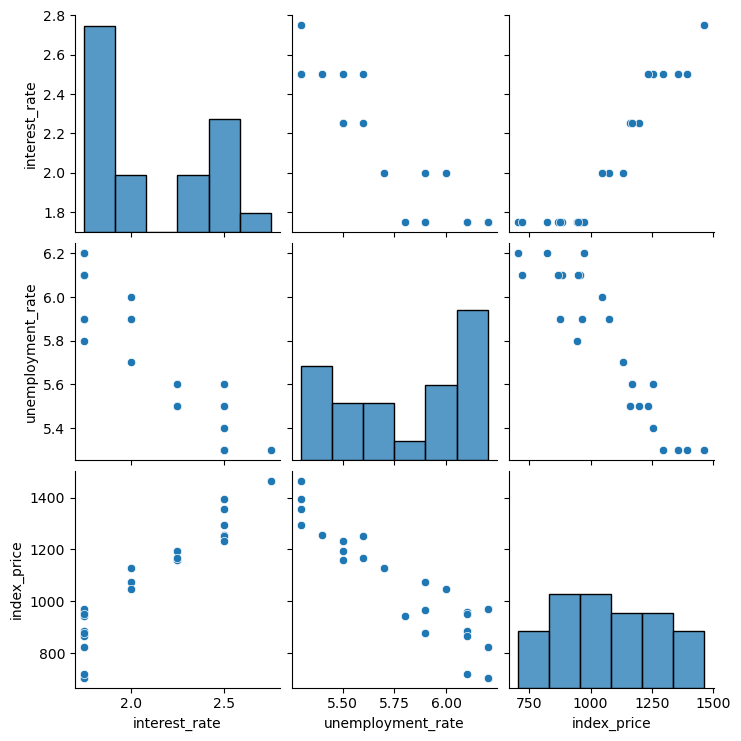

In [11]:
sns.pairplot(df)

Text(0, 0.5, 'index_price')

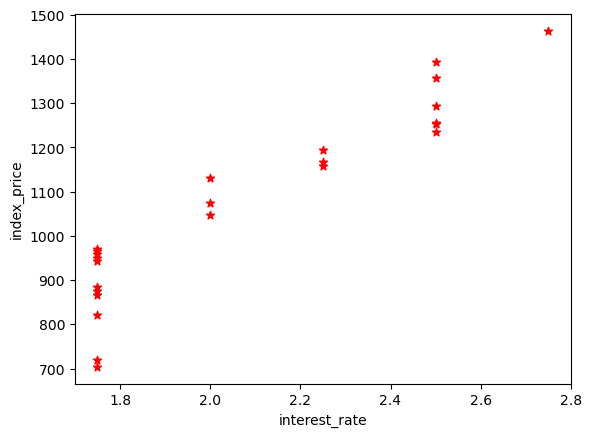

In [14]:
plt.scatter(df['interest_rate'],df['index_price'],color='red',marker='*')
plt.xlabel('interest_rate')
plt.ylabel('index_price')

Text(0, 0.5, 'unemployement_rate')

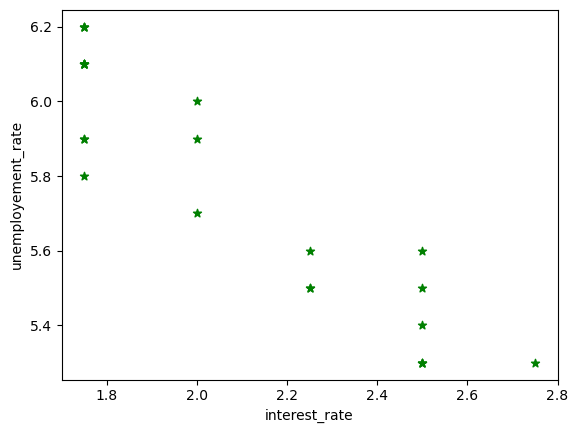

In [16]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='green',marker='*')
plt.xlabel('interest_rate')
plt.ylabel('unemployement_rate')

Text(0, 0.5, 'index_price')

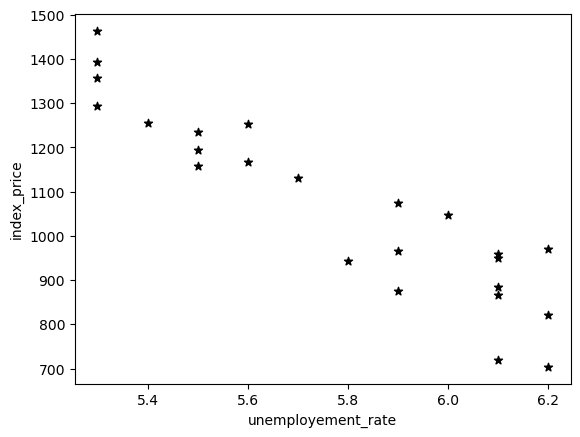

In [18]:
plt.scatter(df['unemployment_rate'],df['index_price'],color='black',marker='*')
plt.xlabel('unemployement_rate')
plt.ylabel('index_price')

In [19]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: xlabel='interest_rate', ylabel='index_price'>

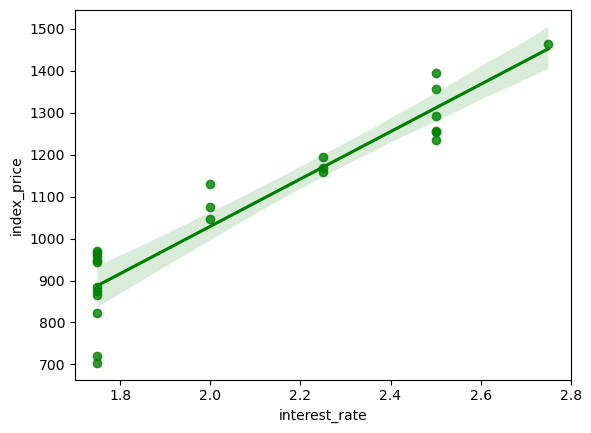

In [21]:
sns.regplot(x=df['interest_rate'],y=df['index_price'],color='green')

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

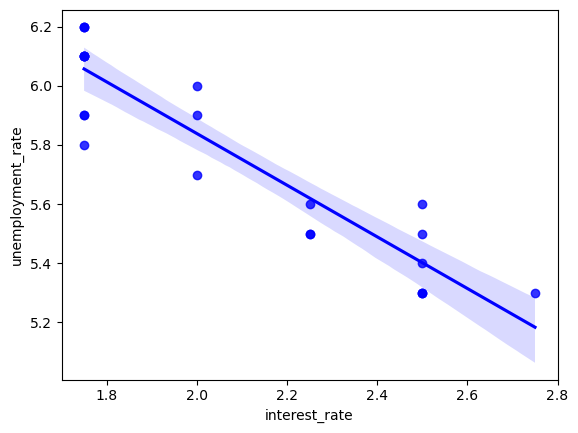

In [22]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'],color='blue')

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

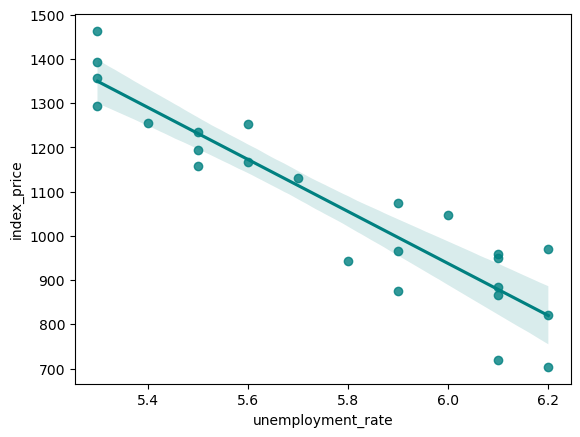

In [24]:
sns.regplot(y=df['index_price'],x=df['unemployment_rate'],color='teal')

<Axes: xlabel='unemployment_rate', ylabel='Density'>

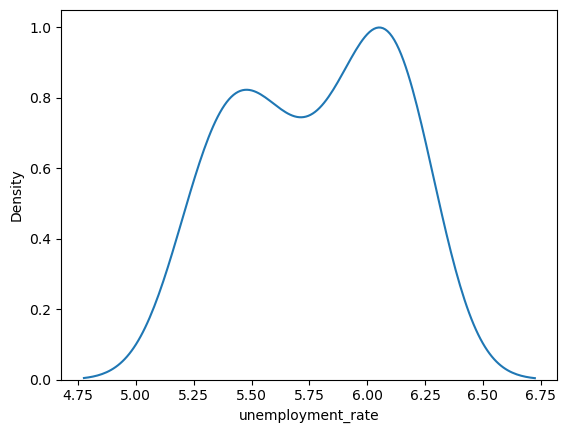

In [27]:
sns.kdeplot(df['unemployment_rate'])

<Axes: xlabel='interest_rate', ylabel='Density'>

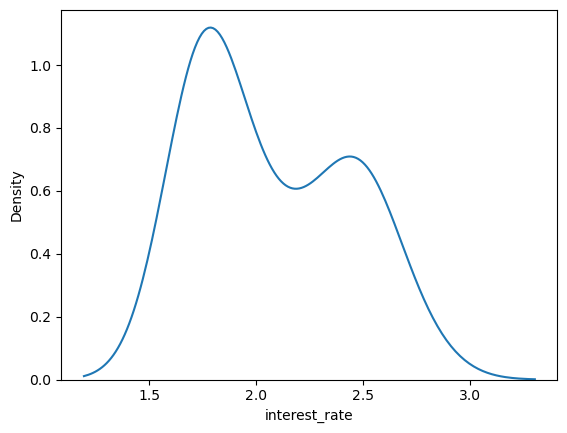

In [28]:
sns.kdeplot(df['interest_rate'])

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [30]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)

In [31]:
x_test=scaler.transform(x_test)

In [32]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
y_pred=model.predict(x_test)

In [35]:
#Errors
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error
MSE=mean_squared_error(y_test,y_pred)
MAE=mean_absolute_error(y_test,y_pred)
RMSE=root_mean_squared_error(y_test,y_pred)
print("Root Mean suqare error:",MSE)
print("Mean Absolute Error :",MAE)
print("Root Mean Square Error :",RMSE)

Root Mean suqare error: 5088.329958294
Mean Absolute Error : 58.95987629034906
Root Mean Square Error : 71.33253085580239


In [36]:
## r2 square
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("The R2 score is :",score)

The R2 score is : 0.8640024299625207


In [38]:
## Adjusted r2 score
Adjusted_r2_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
print(Adjusted_r2_score)

0.8096034019475291


In [39]:
from sklearn.model_selection import cross_val_score
validation=cross_val_score(model,x_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [40]:
print(validation)

[ -8717.80560752 -14492.68332185  -2542.85216034]


In [41]:
print(np.mean(validation))

-8584.447029905596


In [42]:
import statsmodels.api as sm
model_ols=sm.OLS(y_train,x_train).fit()

In [43]:
y_predic=model_ols.predict(x_test)

In [44]:
print(model_ols.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.105
Method:                 Least Squares   F-statistic:                             0.2425
Date:                Sat, 26 Sep 2026   Prob (F-statistic):                       0.788
Time:                        15:05:48   Log-Likelihood:                         -133.85
No. Observations:                  16   AIC:                                      271.7
Df Residuals:                      14   BIC:                                      273.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [45]:
print(model.coef_)
print(model.intercept_)

[  96.28689501 -101.57024663]
1037.6875
